# 第8回課題: タイタニック号 生存予測コンペ — 提出用ノートブック

`train_titanic.csv`（712件）で学習した二値分類モデルにより、`test_titanic.csv`（179件）の生存ラベル（`Survived`）を予測します。
評価指標は **`Survived = 1`（生存）を正例とした F1 スコア** です（`lesson8_regulation.md` 参照）。

## 方針

1. **リークのない前処理**: 欠損補完・エンコーディング・グループ統計はすべて「学習側データのみ」で fit し、検証・テストデータには適用（transform）のみ行う。交差検証でも fold ごとに fit をやり直す。
2. **家族・同行者グループの生存率特徴**: タイタニックでは家族・同行者が運命を共にする傾向が強い。学習データのラベルから「同じチケット / 同じ姓のグループの女性・子供の生存率」を作り、最も強い特徴量として使う。
3. **繰り返し層化交差検証（5-fold × 4回）の OOF 予測**で汎化性能を測り、**F1 を最大化する判定しきい値も OOF だけで決める**（レギュレーション 7 の推奨に沿う）。
4. **多様な6モデル + アンサンブル**（ソフト投票・スタッキング）で、性質の異なる提出を最大3本（レギュレーション 5.3 の上限）作る。

## レギュレーションの遵守

- 使用データは配布された `train_titanic.csv` / `test_titanic.csv` のみ（外部データ・既知の正解ラベルは一切使用しない）。
- テストデータは「特徴量への変換」と「最終予測」にのみ使用し、統計量の fit・モデル選択・しきい値決定には一切使わない。
- 最終ラベルはすべてモデルの予測確率としきい値から機械的に決定する（人手による書き換えなし）。
- 乱数シードは 42 に固定し、使用ライブラリのバージョンを記録する（再現性）。

## 提出ファイル（最大3本）

| ファイル | 内容 |
| --- | --- |
| `submission_stacking.csv` | 6モデルの OOF 予測確率を入力とするスタッキング（メタ学習器: ロジスティック回帰） |
| `submission_voting.csv` | OOF 成績上位モデルの予測確率の単純平均（ソフト投票） |
| `submission_best_single_*.csv` | OOF 最良の単一モデル（`*` にはモデル名が入る） |

> **注意**: ハイパーパラメータ探索と交差検証を全部実行するため、ノートブック全体の実行には **10〜15分程度** かかります。

## 目次

1. ライブラリの読み込みと設定
2. データの読み込みと確認
3. 探索的データ分析（EDA）
4. 特徴量エンジニアリング（リーク防止設計）
5. 検証設計（Repeated Stratified K-Fold + OOF + しきい値）
6. モデル定義とハイパーパラメータ探索
7. 各モデルの最終 OOF 評価
8. アンサンブル（ソフト投票・スタッキング）
9. テストデータの予測と提出 CSV の作成
10. まとめ

## 1. ライブラリの読み込みと設定

使用するライブラリを読み込み、乱数シードとバージョンを記録します。
グラフの文字化けを避けるため、図中のラベルは英語表記にしています（説明は本文で行います）。

In [24]:
# 標準ライブラリ
import re          # 氏名から敬称を抜き出す正規表現に使用
import time        # 処理時間の計測に使用
import platform    # 実行環境の記録に使用
import warnings
from pathlib import Path

# 数値計算・表形式データ処理
import numpy as np
import pandas as pd

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

# 機械学習モデルと評価指標（scikit-learn）
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 勾配ブースティング決定木（GBDT）ライブラリ
import lightgbm
import xgboost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

# 再現性のための乱数シード（レギュレーション 5.3 に従い記録する）
SEED = 42

# 実行環境とライブラリバージョンの記録（再現性のため）
print(f"platform     : {platform.platform()}")
print(f"python       : {platform.python_version()}")
for mod in [np, pd, lightgbm, xgboost]:
    print(f"{mod.__name__:<13}: {mod.__version__}")
import sklearn
print(f"scikit-learn : {sklearn.__version__}")

platform     : macOS-14.5-arm64-arm-64bit
python       : 3.11.15
numpy        : 2.4.6
pandas       : 3.0.3
lightgbm     : 4.6.0
xgboost      : 3.2.0
scikit-learn : 1.9.0


## 2. データの読み込みと確認

学習データ（712件・ラベルあり）とテストデータ（179件・ラベルなし）を読み込み、
データ型・欠損・ラベル分布を確認します。

In [25]:
# 配布データの読み込み（このノートブックと同じフォルダにある CSV）
train_df = pd.read_csv(Path("train_titanic.csv"))
test_df = pd.read_csv(Path("test_titanic.csv"))

# 目的変数（0: 死亡, 1: 生存）を numpy 配列として取り出す
y = train_df["Survived"].to_numpy()

# 学習データから目的変数列を除いたもの（特徴量作成に使う）
train_X_raw = train_df.drop(columns=["Survived"])

print(f"学習データ: {train_df.shape}, テストデータ: {test_df.shape}")
train_df.head()

学習データ: (712, 12), テストデータ: (179, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,503,0,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,NaN,Q
1,465,0,3,"Maisner, Mr. Simon",male,NaN,0,0,A/S 2816,8.0500,NaN,S
2,199,1,3,"Madigan, Miss. Margaret ""Maggie""",female,NaN,0,0,370370,7.7500,NaN,Q
3,766,1,1,"Hogeboom, Mrs. John C (Anna Andrews)",female,51.0,1,0,13502,77.9583,D11,S
4,422,0,3,"Charters, Mr. David",male,21.0,0,0,A/5. 13032,7.7333,NaN,Q


In [26]:
# 欠損値の数とラベル分布を確認する
missing = pd.DataFrame({
    "train_missing": train_df.drop(columns=["Survived"]).isna().sum(),
    "test_missing": test_df.isna().sum(),
})
display(missing[missing.sum(axis=1) > 0])

# ラベル分布: 生存 38.3% / 死亡 61.7% とやや不均衡 → F1（正例=生存）で評価される点に注意
label_dist = train_df["Survived"].value_counts().to_frame("count")
label_dist["ratio"] = (label_dist["count"] / len(train_df)).round(4)
display(label_dist)

,train_missing,test_missing
Age,146,31
Cabin,552,135
Embarked,2,0


,count,ratio
Survived,,
0,439,0.6166
1,273,0.3834


## 3. 探索的データ分析（EDA）

モデルに入れる前に、どの変数が生存と強く関係するかを確認します。
タイタニックの救命ボートは「女性と子供優先」だったことが知られており、
性別・年齢・客室等級（社会階級）の効果が大きいはずです。

In [27]:
# 性別・客室等級ごとの生存率（クロス集計）
print("性別ごとの生存率:")
display(train_df.groupby("Sex")["Survived"].agg(["mean", "count"]).round(3))

print("客室等級ごとの生存率:")
display(train_df.groupby("Pclass")["Survived"].agg(["mean", "count"]).round(3))

print("性別 × 客室等級の生存率:")
display(train_df.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="mean").round(3))

性別ごとの生存率:


,mean,count
Sex,,
female,0.745,251
male,0.187,461


客室等級ごとの生存率:


,mean,count
Pclass,,
1,0.630,173
2,0.493,150
3,0.231,389


性別 × 客室等級の生存率:


Pclass,1,2,3
Sex,,,
female,0.973,0.908,0.495
male,0.367,0.176,0.126


In [28]:
# 家族人数（本人 + 同乗の兄弟姉妹・配偶者 + 親子）ごとの生存率
family_size = train_df["SibSp"] + train_df["Parch"] + 1
print("家族人数ごとの生存率（2〜4人の中規模家族が有利、5人以上の大家族と単身は不利）:")
display(train_df.groupby(family_size.rename("FamilySize"))["Survived"].agg(["mean", "count"]).round(3))

家族人数ごとの生存率（2〜4人の中規模家族が有利、5人以上の大家族と単身は不利）:


,mean,count
FamilySize,,
1,0.302,431
2,0.556,133
3,0.579,76
4,0.739,23
5,0.231,13
6,0.118,17
7,0.300,10
8,0.000,5
11,0.000,4


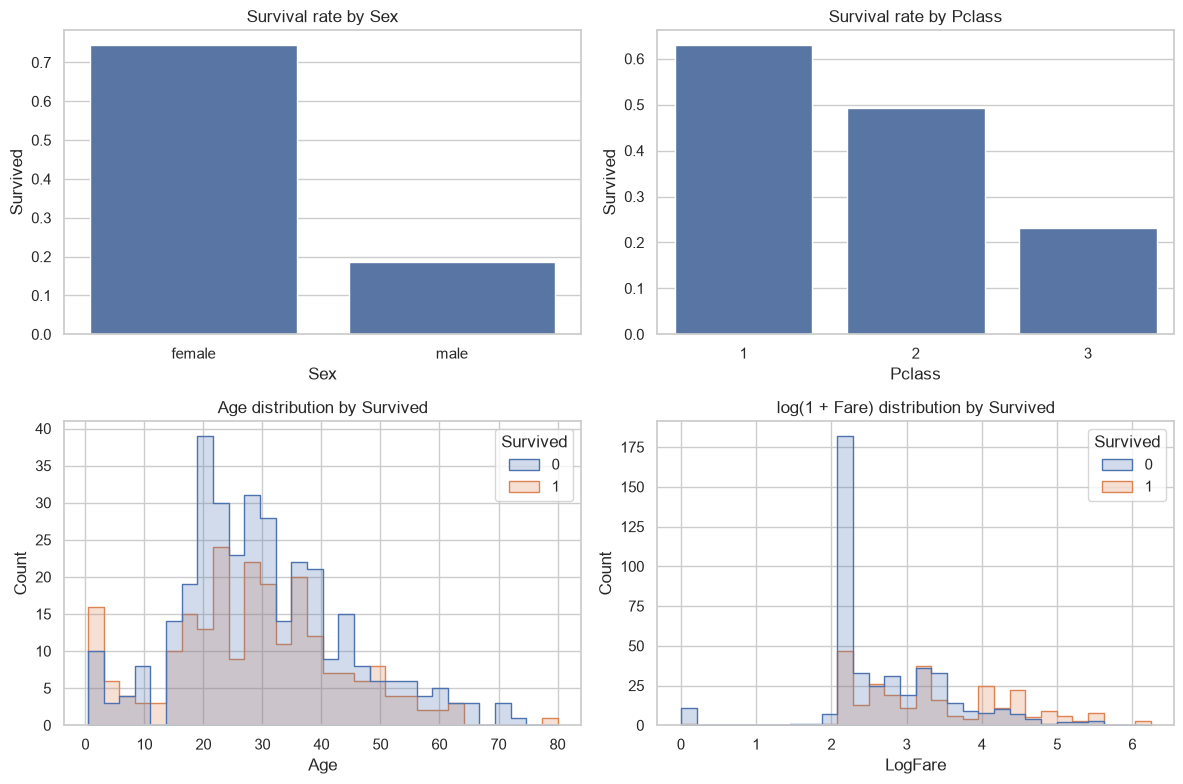

In [29]:
# 主要な変数と生存の関係をまとめて可視化する
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) 性別ごとの生存率
sns.barplot(data=train_df, x="Sex", y="Survived", ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title("Survival rate by Sex")

# (b) 客室等級ごとの生存率
sns.barplot(data=train_df, x="Pclass", y="Survived", ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title("Survival rate by Pclass")

# (c) 年齢分布（生存/死亡別）: 子供の生存率が高い
sns.histplot(data=train_df, x="Age", hue="Survived", bins=30, ax=axes[1, 0], element="step")
axes[1, 0].set_title("Age distribution by Survived")

# (d) 運賃（対数スケール）: 高運賃ほど生存しやすい
sns.histplot(
    data=train_df.assign(LogFare=np.log1p(train_df["Fare"])),
    x="LogFare", hue="Survived", bins=30, ax=axes[1, 1], element="step",
)
axes[1, 1].set_title("log(1 + Fare) distribution by Survived")

plt.tight_layout()
plt.show()

**EDA の所見**

- 女性の生存率は約 75%、男性は約 19% と、性別が圧倒的に強い変数。
- 客室等級が上がるほど生存率が高い（1等 ≈ 63% > 2等 ≈ 49% > 3等 ≈ 23%）。
- 子供（低年齢）の生存率が高く、運賃が高いほど生存しやすい。
- 家族人数は 2〜4 人で有利、単身・5人以上で不利という非線形な関係。

→ これらを捉える特徴量に加えて、「**同じ家族・同行者グループはボートに一緒に乗る（=運命を共にする）**」という
構造を学習ラベルから特徴量化することで、単純な属性だけでは当てられない乗客を狙います。

## 4. 特徴量エンジニアリング（リーク防止設計）

前処理は次の2段階に分け、**fit はつねに学習側データのみ**で行います（レギュレーション 2.3・チェックリストの要求）。

- `fit_feature_state(学習側データ, ラベル)` → 補完値・グループ統計などの「状態」を学習
- `transform_features(任意のデータ, 状態)` → 状態を使って特徴量行列へ変換

交差検証でも fold ごとに fit をやり直すので、検証・テストデータの情報が学習側へ漏れません。

**作成する特徴量の一覧**

| 特徴量 | 内容 |
| --- | --- |
| `Title`（One-hot） | 氏名の敬称を Mr / Mrs / Miss / Master / Rare の5種類に集約。Master は少年、Rare は聖職者・軍人・貴族など |
| `IsFemale` | 性別（female = 1） |
| `Age`, `AgeMissing`, `IsChild` | 年齢は（敬称 × 等級）別の中央値で補完。欠損フラグと子供フラグ（14歳以下）も追加 |
| `FamilySize`, `IsAlone`, `FamilyBucket`（One-hot） | 家族人数 = SibSp + Parch + 1、単身フラグ、単身/中規模(2-4)/大家族(5+) の区分 |
| `TicketGroupSize` | 同じチケット番号の人数（学習側データで数える）。チケットは同行者グループの手がかり |
| `LogFare`, `LogFarePerTicket`, `LogFarePerFamily` | 運賃と「1人あたり運賃」の対数。Fare はチケット単位の合計金額のため人数で割ると意味が明確になる |
| `DeckGroup`（One-hot）, `HasCabin` | 客室番号の頭文字（デッキ）を上層 ABC / 中層 DE / 下層 FG / 不明 M に集約 |
| `Embarked`（One-hot） | 乗船港（欠損は学習側の最頻値で補完） |
| `NameLength` | 氏名の文字数。既婚女性の旧姓併記や貴族の称号で長くなり、社会的地位の代理変数になる |
| `Pclass`, `Pclass_k`, `FemalePclass_k` | 客室等級（数値と One-hot）および性別との交互作用（「3等の女性は生存率が下がる」を線形モデルでも表現できるようにする） |
| **`WCRate* / WCCount* / WCInfo*`** | **同一グループ（チケット / 姓×等級）の「女性・子供」の生存率**（下で詳述） |

**グループ生存率特徴（この解法の要）**

家族・同行者はボートに一緒に乗ろうとするため、「同じグループの女性・子供が生存したか」は本人の生死の強い手がかりになります。
そこで学習データのラベルから、グループ（同一チケット、および 姓×客室等級）ごとに「女性・子供（女性または敬称 Master の少年）」の生存率を集計し、各乗客に割り当てます。

- **自分自身のラベルは必ず除外して計算**します（leave-one-out）。例: 3人家族の女性・子供が全員学習データにいてうち2人生存の場合、本人が生存者なら「自分以外の生存率 = 1/2」。自分を含めるとラベルそのものが特徴量に混入し、検証スコアが不正に高くなります。
- 検証・テストの乗客は、学習側データに同じグループの女性・子供がいる場合のみ値を持ちます（いなければ欠損扱い → 学習側の全体平均で埋め、`WCInfo* = 0` で「情報なし」を表現）。

In [30]:
# 敬称の集約マップ（少数派の敬称は "Rare" にまとめる）
TITLE_MAP = {
    "Mr": "Mr",
    "Mrs": "Mrs",
    "Miss": "Miss",
    "Master": "Master",
    "Mme": "Mrs",    # フランス語の Madame
    "Ms": "Miss",
    "Mlle": "Miss",  # フランス語の Mademoiselle
}

# デッキ（客室の頭文字）の集約マップ: 上層 / 中層 / 下層 / 不明
DECK_MAP = {"A": "ABC", "B": "ABC", "C": "ABC", "D": "DE", "E": "DE", "F": "FG", "G": "FG", "T": "M"}

# One-hot encoding の水準を固定する（fold や train/test で列がずれないようにする）
CAT_LEVELS = {
    "Title": ["Mr", "Mrs", "Miss", "Master", "Rare"],
    "DeckGroup": ["ABC", "DE", "FG", "M"],
    "Embarked": ["C", "Q", "S"],
    "FamilyBucket": ["solo", "small", "large"],
}


def extract_title(name):
    """氏名から敬称（Mr, Mrs, ...）を取り出して5種類に集約する。"""
    m = re.search(r",\s*([^.]+)\.", name)
    raw = m.group(1).strip() if m else ""
    return TITLE_MAP.get(raw, "Rare")


def extract_surname(name):
    """氏名の先頭（カンマの前）にある姓を取り出す。"""
    return name.split(",")[0].strip()


def add_basic_features(df):
    """行単位で完結する（他の行の情報を使わない）特徴量を追加する。"""
    out = df.copy()
    out["Title"] = out["Name"].map(extract_title)
    out["Surname"] = out["Name"].map(extract_surname)
    # 姓 + 客室等級 をグループ判定キーにする（同姓の無関係な家族の混同を減らす）
    out["SurnameKey"] = out["Surname"] + "|" + out["Pclass"].astype(str)
    out["IsFemale"] = (out["Sex"] == "female").astype(int)
    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    out["IsAlone"] = (out["FamilySize"] == 1).astype(int)
    out["FamilyBucket"] = pd.cut(
        out["FamilySize"], bins=[0, 1, 4, 20], labels=["solo", "small", "large"]
    ).astype(str)
    out["DeckGroup"] = out["Cabin"].str[0].map(DECK_MAP).fillna("M")
    out["HasCabin"] = out["Cabin"].notna().astype(int)
    out["NameLength"] = out["Name"].str.len().astype(int)
    out["AgeMissing"] = out["Age"].isna().astype(int)
    return out


# 動作確認: 敬称ごとの生存率（Master = 少年の生存率が男性平均より大幅に高い）
_tmp = add_basic_features(train_X_raw)
display(pd.DataFrame({"Survived": y}).groupby(_tmp["Title"])["Survived"].agg(["mean", "count"]).round(3))

,mean,count
Title,,
Master,0.571,35
Miss,0.703,145
Mr,0.154,409
Mrs,0.798,104
Rare,0.263,19


In [31]:
def _wc_group_stats(feat_df, y, key_col):
    """グループ（同一チケット or 同姓×等級）ごとに「女性・子供」の生存数と人数を集計する。

    「女性・子供」= 女性、または敬称が Master（少年）。
    学習側データのみから作る（テストデータの行は一切数えない）。
    """
    stats = {}
    is_wc = (feat_df["IsFemale"].to_numpy() == 1) | (feat_df["Title"].to_numpy() == "Master")
    for key, surv, wc in zip(feat_df[key_col].to_numpy(), y, is_wc):
        if not wc:
            continue
        s = stats.setdefault(key, [0, 0])
        s[0] += int(surv)
        s[1] += 1
    return stats


def fit_feature_state(train_feat, y):
    """学習側データだけを使って、変換に必要な統計量（状態）を学習する。

    ここで作った統計を検証・テストデータへ「適用」するだけにすることで、
    テストデータの情報が学習側へ漏れることを防ぐ。
    train_feat は add_basic_features 適用済みのデータフレーム。
    """
    state = {}
    state["embarked_mode"] = train_feat["Embarked"].mode().iloc[0]
    state["fare_median"] = float(train_feat["Fare"].median())
    # 年齢の補完値: (敬称×等級) の中央値 → 敬称の中央値 → 全体中央値 の順で参照
    state["age_by_title_pclass"] = (
        train_feat.groupby(["Title", "Pclass"])["Age"].median().to_dict()
    )
    state["age_by_title"] = train_feat.groupby("Title")["Age"].median().to_dict()
    state["age_global"] = float(train_feat["Age"].median())
    # チケット文字列 → 学習側での同一チケット人数
    state["ticket_counts"] = train_feat["Ticket"].value_counts().to_dict()
    # 女性・子供グループの生存統計（チケット単位・姓×等級単位）
    state["wc_ticket"] = _wc_group_stats(train_feat, y, "Ticket")
    state["wc_surname"] = _wc_group_stats(train_feat, y, "SurnameKey")
    is_wc = (train_feat["IsFemale"].to_numpy() == 1) | (train_feat["Title"].to_numpy() == "Master")
    state["global_wc_rate"] = float(y[is_wc].mean()) if is_wc.any() else 0.5
    return state


def _lookup_age(state, title, pclass):
    """年齢補完値をフォールバック付きで引く。"""
    v = state["age_by_title_pclass"].get((title, pclass), np.nan)
    if pd.isna(v):
        v = state["age_by_title"].get(title, np.nan)
    if pd.isna(v):
        v = state["age_global"]
    return float(v)


def _wc_group_features(feat_df, state_key, y_for_loo, default_rate, key_col):
    """各行に「同グループの女性・子供の生存率」を割り当てる。

    - 学習側の行（y_for_loo あり）: 自分自身を除外して計算する（leave-one-out）。
    - 検証・テストの行（y_for_loo なし）: 学習側の統計をそのまま参照する。
    """
    is_wc = (feat_df["IsFemale"].to_numpy() == 1) | (feat_df["Title"].to_numpy() == "Master")
    keys = feat_df[key_col].to_numpy()
    n = len(feat_df)
    rate = np.full(n, default_rate)
    size = np.zeros(n)
    has_info = np.zeros(n, dtype=int)
    for i in range(n):
        s = state_key.get(keys[i])
        if s is None:
            continue
        ssum, cnt = s
        if y_for_loo is not None and is_wc[i]:
            # 自分自身のラベルを集計から除く（ラベル混入 = リークの防止）
            ssum -= int(y_for_loo[i])
            cnt -= 1
        if cnt <= 0:
            continue
        rate[i] = ssum / cnt
        size[i] = cnt
        has_info[i] = 1
    return rate, size, has_info

In [32]:
def transform_features(df, state, y_for_loo=None):
    """fit 済みの状態 state を使ってデータフレームを数値特徴量行列へ変換する。

    y_for_loo には「state を fit したデータ自身を変換する場合」のみ、そのラベルを渡す
    （グループ生存率の leave-one-out 計算と、チケット人数の自己カウント調整に使う）。
    """
    feat = add_basic_features(df)
    is_reference = y_for_loo is not None

    # --- 欠損補完（state に保存した学習側の統計のみ使用） ---
    feat["Embarked"] = feat["Embarked"].fillna(state["embarked_mode"])
    feat["Fare"] = feat["Fare"].fillna(state["fare_median"])
    age_fill = [_lookup_age(state, t, p) for t, p in zip(feat["Title"], feat["Pclass"])]
    feat["Age"] = feat["Age"].fillna(pd.Series(age_fill, index=feat.index))
    feat["IsChild"] = (feat["Age"] <= 14).astype(int)

    # --- チケットグループ人数と1人あたり運賃 ---
    # 学習側の行は state のカウントに自身が含まれる。検証・テストの行は含まれないので +1 する。
    self_add = 0 if is_reference else 1
    feat["TicketGroupSize"] = [
        state["ticket_counts"].get(t, 0) + self_add for t in feat["Ticket"]
    ]
    feat["TicketGroupSize"] = feat["TicketGroupSize"].clip(lower=1)
    feat["LogFare"] = np.log1p(feat["Fare"])
    feat["LogFarePerTicket"] = np.log1p(feat["Fare"] / feat["TicketGroupSize"])
    feat["LogFarePerFamily"] = np.log1p(feat["Fare"] / feat["FamilySize"])

    # --- 女性・子供グループの生存率特徴（本命の特徴量） ---
    g = state["global_wc_rate"]
    for key_col, name in [("Ticket", "Ticket"), ("SurnameKey", "Surname")]:
        stats = state["wc_ticket"] if key_col == "Ticket" else state["wc_surname"]
        rate, size, has = _wc_group_features(feat, stats, y_for_loo, g, key_col)
        feat[f"WCRate{name}"] = rate
        feat[f"WCCount{name}"] = size
        feat[f"WCInfo{name}"] = has

    # --- 数値行列の組み立て ---
    numeric_cols = [
        "Pclass", "IsFemale", "Age", "AgeMissing", "IsChild", "SibSp", "Parch",
        "FamilySize", "IsAlone", "HasCabin", "NameLength", "TicketGroupSize",
        "LogFare", "LogFarePerTicket", "LogFarePerFamily",
        "WCRateTicket", "WCCountTicket", "WCInfoTicket",
        "WCRateSurname", "WCCountSurname", "WCInfoSurname",
    ]
    X = feat[numeric_cols].astype(float).copy()
    for col, levels in CAT_LEVELS.items():
        cat = pd.Categorical(feat[col], categories=levels)
        dummies = pd.get_dummies(cat, prefix=col).astype(int)
        X = pd.concat([X, dummies.set_axis(X.index)], axis=1)
    # 性別×客室等級の交互作用（線形モデルが「3等の女性は生存率が下がる」等を表現できるようにする）
    for k in [1, 2, 3]:
        X[f"Pclass_{k}"] = (feat["Pclass"] == k).astype(int)
        X[f"FemalePclass_{k}"] = X[f"Pclass_{k}"] * feat["IsFemale"]
    return X

In [33]:
# 動作確認: 学習データ全体で fit し、学習・テスト両方を変換してみる
state_check = fit_feature_state(add_basic_features(train_X_raw), y)
X_check = transform_features(train_X_raw, state_check, y_for_loo=y)
X_test_check = transform_features(test_df, state_check)

print(f"特徴量行列: 学習 {X_check.shape}, テスト {X_test_check.shape}")

# グループ生存率特徴を持つ乗客の割合（テスト乗客の約25%は学習側に家族・同行者がいる）
print("グループ情報を持つ割合（学習側, LOO後）:",
      X_check[["WCInfoTicket", "WCInfoSurname"]].mean().round(3).to_dict())
print("グループ情報を持つ割合（テスト側）   :",
      X_test_check[["WCInfoTicket", "WCInfoSurname"]].mean().round(3).to_dict())

# 列の一致と欠損なしを保証する（モデルによっては欠損を扱えないため）
assert list(X_check.columns) == list(X_test_check.columns)
assert not X_check.isna().any().any() and not X_test_check.isna().any().any()
print(f"OK: 列の一致・欠損なしを確認（特徴量 {X_check.shape[1]} 列）")

特徴量行列: 学習 (712, 42), テスト (179, 42)
グループ情報を持つ割合（学習側, LOO後）: {'WCInfoTicket': 0.246, 'WCInfoSurname': 0.209}
グループ情報を持つ割合（テスト側）   : {'WCInfoTicket': 0.263, 'WCInfoSurname': 0.268}
OK: 列の一致・欠損なしを確認（特徴量 42 列）


## 5. 検証設計（Repeated Stratified K-Fold + OOF + しきい値）

**Out-of-Fold（OOF）予測**: 層化 5-fold 交差検証で「自分が学習に使われていない fold のモデル」による予測確率を全 712 件に割り当てたもの。
学習データ全体に対する「見たことのないデータへの予測」が得られるので、汎化性能の見積もりやしきい値の決定に使えます。

- 分割の乱数による偶然を抑えるため、**乱数シードを変えて4回繰り返し**、平均±標準偏差で判断します（レギュレーション 7「単一の分割結果だけで判断せず」）。
- **fold ごとに特徴量の fit をやり直す**ため、検証データの情報は前処理にも漏れません。
- F1（正例=生存）は正例が少ないデータではしきい値 0.5 が最適とは限りません。**OOF 予測に対して F1 が最大になるしきい値**を探索します（テストの正解は一切使いません）。
- モデル選択・ハイパーパラメータ選択には、しきい値に依存しない **Average Precision（PR 曲線の下面積、AP）** を使います。F1 で直接選ぶよりしきい値ノイズの影響を受けにくいためです。

In [34]:
# F1 最適化で探索する判定しきい値の候補
THRESHOLDS = np.round(np.arange(0.10, 0.91, 0.01), 2)


def compute_oof(model_factory, train_df, y, n_splits=5, n_repeats=4, base_seed=SEED):
    """繰り返し層化 K-Fold で out-of-fold (OOF) 予測確率を作る。

    fold ごとに特徴量の fit をやり直すことで、検証データの情報が
    前処理へ漏れない状態で汎化性能を測る。
    戻り値: shape (n_repeats, n_samples) の予測確率
    """
    oof = np.zeros((n_repeats, len(y)))
    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=base_seed + 100 * r)
        for tr_idx, va_idx in skf.split(train_df, y):
            tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
            va_df = train_df.iloc[va_idx].reset_index(drop=True)
            y_tr = y[tr_idx]
            # 前処理の fit は学習 fold のみ（検証 fold の情報は使わない）
            state = fit_feature_state(add_basic_features(tr_df), y_tr)
            X_tr = transform_features(tr_df, state, y_for_loo=y_tr)
            X_va = transform_features(va_df, state)
            model = model_factory()
            model.fit(X_tr, y_tr)
            oof[r, va_idx] = model.predict_proba(X_va)[:, 1]
    return oof


def oof_metrics(oof, y):
    """OOF 予測から AP / AUC / F1（最適しきい値）を計算する。"""
    n_repeats = oof.shape[0]
    ap = [average_precision_score(y, oof[r]) for r in range(n_repeats)]
    auc = [roc_auc_score(y, oof[r]) for r in range(n_repeats)]
    # しきい値ごとの F1 を repeat 平均し、最も高いしきい値を選ぶ
    f1_curve = np.zeros((n_repeats, len(THRESHOLDS)))
    for r in range(n_repeats):
        for j, t in enumerate(THRESHOLDS):
            f1_curve[r, j] = f1_score(y, (oof[r] >= t).astype(int))
    mean_curve = f1_curve.mean(axis=0)
    best_mean = mean_curve.max()
    # 最大値近傍（差 0.002 以内）のしきい値の中央を採用してノイズに頑健にする
    near = THRESHOLDS[mean_curve >= best_mean - 0.002]
    best_t = float(np.median(near))
    j_best = int(np.argmin(np.abs(THRESHOLDS - best_t)))
    return {
        "ap_mean": float(np.mean(ap)), "ap_std": float(np.std(ap)),
        "auc_mean": float(np.mean(auc)), "auc_std": float(np.std(auc)),
        "f1_mean": float(mean_curve[j_best]), "f1_std": float(f1_curve[:, j_best].std()),
        "threshold": best_t,
    }

In [35]:
# 比較の基準: 「女性なら生存」と予測するだけのルール（モデルなし）の F1
baseline_f1 = f1_score(y, (train_df["Sex"] == "female").astype(int))
print(f"性別のみベースライン（女性=生存）の F1: {baseline_f1:.4f}")
print("→ 機械学習モデルはこれを明確に上回る必要がある")

性別のみベースライン（女性=生存）の F1: 0.7137
→ 機械学習モデルはこれを明確に上回る必要がある


## 6. モデル定義とハイパーパラメータ探索

性質の異なる6つのモデルを使います（アンサンブルは多様なモデルほど効果的）。

| モデル | 特徴 |
| --- | --- |
| LogisticRegression | 線形モデル。標準化とセットで使用。解釈しやすく、交互作用特徴で補強 |
| RandomForest | 決定木のバギング。過学習に強く小データで安定 |
| ExtraTrees | 分割にも乱数を使う RandomForest の変種。より分散が小さい |
| HistGradientBoosting | scikit-learn 組み込みの GBDT |
| LightGBM | 勾配ブースティング決定木（leaf-wise 成長） |
| XGBoost | 勾配ブースティング決定木（正則化が豊富） |

- 探索は 5-fold × 2 回の OOF・AP 基準で行い、**最終評価（5-fold × 4 回）とは別の分割シード**を使って選択バイアスを抑えます。
- 712 件と小規模なので、グリッドは過学習しにくい範囲（浅い木・強めの正則化）に絞ります。
- **シードバギング**: 木系モデルは乱数シードで結果が揺れるため、シード違いの3つのモデルの予測確率を平均して安定させます（探索時は時間節約のため単一シード）。

In [36]:
def build_model(name, params, seed=SEED):
    """モデル名とハイパーパラメータから学習器を1つ作る。"""
    p = params.get(name, {})
    if name == "LogisticRegression":
        # 線形モデルはスケールの影響を受けるため標準化とパイプラインにする
        return make_pipeline(
            StandardScaler(), LogisticRegression(max_iter=5000, random_state=seed, **p)
        )
    if name == "RandomForest":
        return RandomForestClassifier(n_estimators=600, random_state=seed, n_jobs=-1, **p)
    if name == "ExtraTrees":
        return ExtraTreesClassifier(n_estimators=600, random_state=seed, n_jobs=-1, **p)
    if name == "HistGB":
        return HistGradientBoostingClassifier(random_state=seed, early_stopping=False, **p)
    if name == "LightGBM":
        return LGBMClassifier(
            random_state=seed, verbosity=-1, subsample=0.8, subsample_freq=1,
            colsample_bytree=0.8, reg_lambda=1.0, **p
        )
    if name == "XGBoost":
        return XGBClassifier(
            random_state=seed, tree_method="hist", eval_metric="logloss",
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, **p
        )
    raise ValueError(name)


MODEL_NAMES = ["LogisticRegression", "RandomForest", "ExtraTrees", "HistGB", "LightGBM", "XGBoost"]

# シードバギング: 乱数シード違いの同一モデルの予測確率を平均し、乱数由来のばらつきを抑える
BAG_SEEDS = [SEED, SEED + 100, SEED + 200]


class SeedBaggedModel:
    """乱数シード違いの同一モデルを複数学習し、予測確率を平均するラッパー。"""

    def __init__(self, name, params, seeds=BAG_SEEDS):
        self.models = [build_model(name, params, seed=s) for s in seeds]

    def fit(self, X, y):
        for m in self.models:
            m.fit(X, y)
        return self

    def predict_proba(self, X):
        return np.mean([m.predict_proba(X) for m in self.models], axis=0)


def make_factories(params, bagged=False):
    """モデル名 → モデル生成関数 の辞書を作る。bagged=True でシードバギング版。"""
    if bagged:
        return {n: (lambda n=n: SeedBaggedModel(n, params)) for n in MODEL_NAMES}
    return {n: (lambda n=n: build_model(n, params)) for n in MODEL_NAMES}


# 各モデルの探索グリッド（小データなので控えめな範囲に絞る）
GRIDS = {
    "LogisticRegression": [{"C": c} for c in [0.05, 0.1, 0.3, 1.0, 3.0]],
    "RandomForest": [
        {"min_samples_leaf": l, "max_features": f}
        for l in [1, 2, 4] for f in ["sqrt", 0.5]
    ],
    "ExtraTrees": [
        {"min_samples_leaf": l, "max_features": f}
        for l in [1, 2, 4] for f in ["sqrt", 0.5]
    ],
    "HistGB": [
        {"learning_rate": lr, "max_leaf_nodes": nl, "min_samples_leaf": 20,
         "max_iter": 250, "l2_regularization": 1.0}
        for lr in [0.05, 0.1] for nl in [15, 31]
    ],
    "LightGBM": [
        {"learning_rate": lr, "n_estimators": ne, "num_leaves": nl, "min_child_samples": ms}
        for lr, ne in [(0.03, 500), (0.06, 300)]
        for nl in [7, 15] for ms in [10, 20]
    ],
    "XGBoost": [
        {"learning_rate": lr, "n_estimators": ne, "max_depth": d, "min_child_weight": w}
        for lr, ne in [(0.03, 500), (0.06, 300)]
        for d in [3, 4] for w in [1, 5]
    ],
}

In [37]:
# ハイパーパラメータ探索（このセルは数分かかります）
# 探索用の分割シード base_seed=7 は最終評価（base_seed=42）と別にして選択バイアスを抑える
t0 = time.time()
best_params = {}
for name, grid in GRIDS.items():
    best_ap, best_p = -1.0, None
    for p in grid:
        factory = make_factories({name: p})[name]
        oof = compute_oof(factory, train_X_raw, y, n_repeats=2, base_seed=7)
        ap = np.mean([average_precision_score(y, oof[r]) for r in range(oof.shape[0])])
        if ap > best_ap:
            best_ap, best_p = ap, p
    best_params[name] = best_p
    print(f"{name:<20} 探索AP={best_ap:.4f}  採用パラメータ: {best_p}  ({time.time()-t0:.0f}s)")

LogisticRegression   探索AP=0.8649  採用パラメータ: {'C': 3.0}  (1s)
RandomForest         探索AP=0.8581  採用パラメータ: {'min_samples_leaf': 2, 'max_features': 'sqrt'}  (37s)
ExtraTrees           探索AP=0.8590  採用パラメータ: {'min_samples_leaf': 2, 'max_features': 'sqrt'}  (75s)
HistGB               探索AP=0.8449  採用パラメータ: {'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'max_iter': 250, 'l2_regularization': 1.0}  (145s)
LightGBM             探索AP=0.8587  採用パラメータ: {'learning_rate': 0.06, 'n_estimators': 300, 'num_leaves': 7, 'min_child_samples': 10}  (202s)
XGBoost              探索AP=0.8618  採用パラメータ: {'learning_rate': 0.03, 'n_estimators': 500, 'max_depth': 3, 'min_child_weight': 1}  (239s)


## 7. 各モデルの最終 OOF 評価（シードバギング）

採用したハイパーパラメータで、5-fold × 4 回（分割シードは探索時と別）の OOF 評価を行います。
`threshold` は OOF の F1 を最大化する判定しきい値です（テストの正解は使っていない点に注意）。

In [38]:
# 最終 OOF 評価（このセルも数分かかります）
factories = make_factories(best_params, bagged=True)
oof_dict, results = {}, {}
for name, fac in factories.items():
    oof_dict[name] = compute_oof(fac, train_X_raw, y, n_repeats=4, base_seed=SEED)
    results[name] = oof_metrics(oof_dict[name], y)
    print(f"{name} 完了 ({time.time()-t0:.0f}s)")

results_df = pd.DataFrame(results).T.sort_values("f1_mean", ascending=False)
display(results_df.round(4))

LogisticRegression 完了 (240s)
RandomForest 完了 (273s)
ExtraTrees 完了 (298s)
HistGB 完了 (400s)
LightGBM 完了 (423s)
XGBoost 完了 (447s)


,ap_mean,ap_std,auc_mean,auc_std,f1_mean,f1_std,threshold
RandomForest,0.8553,0.0071,0.8947,0.0039,0.7972,0.0056,0.355
LogisticRegression,0.8554,0.0086,0.8940,0.0029,0.7928,0.0032,0.475
XGBoost,0.8454,0.0092,0.8887,0.0064,0.7917,0.0080,0.325
ExtraTrees,0.8557,0.0087,0.8920,0.0050,0.7912,0.0033,0.270
LightGBM,0.8418,0.0092,0.8878,0.0048,0.7872,0.0175,0.360
HistGB,0.8317,0.0162,0.8818,0.0090,0.7708,0.0093,0.435


## 8. アンサンブル（ソフト投票・スタッキング）

複数モデルの予測確率を組み合わせて、単一モデルより安定した予測を作ります（レギュレーション 5.4）。

- **ソフト投票**: OOF の AP が最良モデルに近い（差 0.015 以内、最低3モデル）モデルの予測確率を単純平均する。
- **スタッキング**: 6モデルの OOF 予測確率（4回の繰り返しの平均）を新たな特徴量とみなし、メタ学習器（ロジスティック回帰）で組み合わせ方自体を学習する。メタ学習器の評価も交差検証で行う。

In [39]:
# --- ソフト投票（確率平均） ---
ap_scores = {n: results[n]["ap_mean"] for n in results}
max_ap = max(ap_scores.values())
# AP が最良に近いモデルだけ平均に参加させる（弱いモデルで平均を汚さない）
members = [n for n, a in ap_scores.items() if a >= max_ap - 0.015]
if len(members) < 3:
    members = sorted(ap_scores, key=ap_scores.get, reverse=True)[:3]
print(f"投票参加モデル: {members}")

oof_vote = np.mean([oof_dict[n] for n in members], axis=0)
m_vote = oof_metrics(oof_vote, y)
print(f"ソフト投票: AP={m_vote['ap_mean']:.4f} F1={m_vote['f1_mean']:.4f}±{m_vote['f1_std']:.4f} "
      f"しきい値={m_vote['threshold']:.2f}")

投票参加モデル: ['LogisticRegression', 'RandomForest', 'ExtraTrees', 'LightGBM', 'XGBoost']
ソフト投票: AP=0.8599 F1=0.8014±0.0060 しきい値=0.30


In [40]:
# --- スタッキング ---
# メタ特徴量 = 各モデルの OOF 予測確率（4回の繰り返しを平均して 712 × 6 の行列にする）
meta_X = np.column_stack([oof_dict[n].mean(axis=0) for n in MODEL_NAMES])

# メタ学習器（ロジスティック回帰）の正則化 C も交差検証で選ぶ
best_meta_ap, best_meta_c, best_meta_oof = -1.0, 1.0, None
for c in [0.1, 0.3, 1.0, 3.0]:
    meta_oof = np.zeros((4, len(y)))
    for r in range(4):
        skf = StratifiedKFold(5, shuffle=True, random_state=SEED + 100 * r)
        for tr_idx, va_idx in skf.split(meta_X, y):
            lr = LogisticRegression(C=c, max_iter=5000, random_state=SEED)
            lr.fit(meta_X[tr_idx], y[tr_idx])
            meta_oof[r, va_idx] = lr.predict_proba(meta_X[va_idx])[:, 1]
    ap = np.mean([average_precision_score(y, meta_oof[r]) for r in range(4)])
    if ap > best_meta_ap:
        best_meta_ap, best_meta_c, best_meta_oof = ap, c, meta_oof

m_stack = oof_metrics(best_meta_oof, y)
print(f"スタッキング (メタLR C={best_meta_c}): AP={m_stack['ap_mean']:.4f} "
      f"F1={m_stack['f1_mean']:.4f}±{m_stack['f1_std']:.4f} しきい値={m_stack['threshold']:.2f}")

スタッキング (メタLR C=3.0): AP=0.8566 F1=0.8059±0.0026 しきい値=0.39


In [41]:
# --- 総合比較（単一モデル + アンサンブル） ---
summary = results_df.copy()
summary.loc["Voting (soft)"] = pd.Series(m_vote)
summary.loc["Stacking"] = pd.Series(m_stack)
summary = summary.sort_values("f1_mean", ascending=False)
display(summary.round(4))

# OOF 最良の単一モデル（提出2に使う）
best_single = max(results, key=lambda n: results[n]["ap_mean"])
print(f"OOF 最良の単一モデル（AP基準）: {best_single}")

# --- 参考: グループ生存率特徴（WC*）を外すとどれだけ下がるか（アブレーション） ---
wc_cols = ["WCRateTicket", "WCCountTicket", "WCInfoTicket",
           "WCRateSurname", "WCCountSurname", "WCInfoSurname"]

def factory_no_wc():
    """最良単一モデルからグループ生存率特徴だけを除いて学習するラッパー。"""
    base = build_model(best_single, best_params)

    class DropWC:
        def fit(self, X, y_):
            self.m = base
            self.m.fit(X.drop(columns=wc_cols), y_)
            return self
        def predict_proba(self, X):
            return self.m.predict_proba(X.drop(columns=wc_cols))
    return DropWC()

m_nowc = oof_metrics(compute_oof(factory_no_wc, train_X_raw, y, n_repeats=4, base_seed=SEED), y)
print(f"{best_single}（WC特徴なし）: AP={m_nowc['ap_mean']:.4f} F1={m_nowc['f1_mean']:.4f}"
      f" → グループ生存率特徴の寄与を確認")

,ap_mean,ap_std,auc_mean,auc_std,f1_mean,f1_std,threshold
Stacking,0.8566,0.0070,0.8992,0.0018,0.8059,0.0026,0.385
Voting (soft),0.8599,0.0084,0.8992,0.0048,0.8014,0.0060,0.300
RandomForest,0.8553,0.0071,0.8947,0.0039,0.7972,0.0056,0.355
LogisticRegression,0.8554,0.0086,0.8940,0.0029,0.7928,0.0032,0.475
XGBoost,0.8454,0.0092,0.8887,0.0064,0.7917,0.0080,0.325
ExtraTrees,0.8557,0.0087,0.8920,0.0050,0.7912,0.0033,0.270
LightGBM,0.8418,0.0092,0.8878,0.0048,0.7872,0.0175,0.360
HistGB,0.8317,0.0162,0.8818,0.0090,0.7708,0.0093,0.435


OOF 最良の単一モデル（AP基準）: ExtraTrees
ExtraTrees（WC特徴なし）: AP=0.8450 F1=0.7856 → グループ生存率特徴の寄与を確認


## 9. テストデータの予測と提出 CSV の作成

採用した前処理・モデルを**学習データ全体（712件）で再学習**し、テスト 179 件を予測します（レギュレーション 6-7）。
判定しきい値は前節までに OOF だけで決めた値を使います。

| 提出 | 予測確率 | しきい値 |
| --- | --- | --- |
| 提出1: スタッキング | 6モデルのテスト予測確率 → メタ学習器 | スタッキングの OOF で決定 |
| 提出2: ソフト投票 | 投票参加モデルのテスト予測確率の平均 | 投票の OOF で決定 |
| 提出3: 最良単一モデル | OOF 最良単一モデルのテスト予測確率 | そのモデルの OOF で決定 |

In [42]:
# 学習データ全体で前処理を fit（テストデータは一切使わない）
state_full = fit_feature_state(add_basic_features(train_X_raw), y)
X_full = transform_features(train_X_raw, state_full, y_for_loo=y)  # 学習側は LOO で自分を除外
X_test = transform_features(test_df, state_full)

# 6モデルすべてを全学習データで再学習し、テストの予測確率を得る（シードバギング）
final_models, test_proba = {}, {}
for name, fac in factories.items():
    final_models[name] = fac().fit(X_full, y)
    test_proba[name] = final_models[name].predict_proba(X_test)[:, 1]

# 提出1: スタッキング（メタ学習器は OOF メタ特徴量で学習し、テストの6確率に適用）
meta_lr = LogisticRegression(C=best_meta_c, max_iter=5000, random_state=SEED)
meta_lr.fit(meta_X, y)
proba_stack = meta_lr.predict_proba(np.column_stack([test_proba[n] for n in MODEL_NAMES]))[:, 1]
pred_stack = (proba_stack >= m_stack["threshold"]).astype(int)

# 提出2: ソフト投票
proba_vote = np.mean([test_proba[n] for n in members], axis=0)
pred_vote = (proba_vote >= m_vote["threshold"]).astype(int)

# 提出3: 最良単一モデル
pred_single = (test_proba[best_single] >= results[best_single]["threshold"]).astype(int)

# サニティチェック: 予測の生存率が学習データの生存率(38.3%)から大きく外れていないか
for label, pred in [("スタッキング", pred_stack), ("ソフト投票", pred_vote), (f"単一 {best_single}", pred_single)]:
    print(f"{label:<18} 予測生存率: {pred.mean():.3f} ({pred.sum()}/{len(pred)}人)")
print(f"提出間の一致率: stack-vote {(pred_stack == pred_vote).mean():.3f}, "
      f"stack-single {(pred_stack == pred_single).mean():.3f}")

スタッキング             予測生存率: 0.380 (68/179人)
ソフト投票              予測生存率: 0.441 (79/179人)
単一 ExtraTrees      予測生存率: 0.453 (81/179人)
提出間の一致率: stack-vote 0.939, stack-single 0.905


In [43]:
def save_submission(pred, filename):
    """提出 CSV を書き出し、レギュレーション 3・10 の形式要件を検査する。"""
    sub = pd.DataFrame({"PassengerId": test_df["PassengerId"], "Survived": pred.astype(int)})
    # --- 提出前チェック（レギュレーション 10） ---
    assert list(sub.columns) == ["PassengerId", "Survived"]          # 列名
    assert len(sub) == 179                                           # 179件を過不足なく
    assert sub["PassengerId"].is_unique                              # ID の重複なし
    assert set(sub["PassengerId"]) == set(test_df["PassengerId"])    # すべてテスト由来
    assert sub["Survived"].isin([0, 1]).all()                        # 0/1 の整数のみ
    sub.to_csv(filename, index=False)
    print(f"保存: {filename}（生存 {sub['Survived'].sum()} 人 / {len(sub)} 人）")
    return sub


sub_stack = save_submission(pred_stack, "submission_stacking.csv")
sub_vote = save_submission(pred_vote, "submission_voting.csv")
sub_single = save_submission(pred_single, f"submission_best_single_{best_single.lower()}.csv")

print()
print("提出ファイルの先頭5行（スタッキング）:")
display(sub_stack.head())

保存: submission_stacking.csv（生存 68 人 / 179 人）
保存: submission_voting.csv（生存 79 人 / 179 人）
保存: submission_best_single_extratrees.csv（生存 81 人 / 179 人）

提出ファイルの先頭5行（スタッキング）:


,PassengerId,Survived
0,154,0
1,753,0
2,611,0
3,201,0
4,311,1


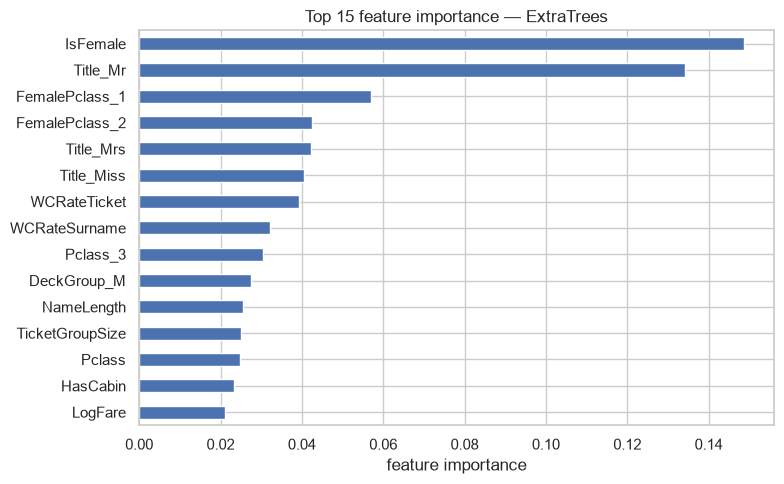

In [44]:
# 参考: 最良単一モデルの特徴量重要度（当日の手法説明用）
bag = final_models[best_single]
if all(hasattr(m, "feature_importances_") for m in bag.models):
    imp = np.mean([m.feature_importances_ for m in bag.models], axis=0)
    imp_label = "feature importance"
elif hasattr(bag.models[0], "named_steps"):  # ロジスティック回帰（パイプライン）の場合は係数の絶対値
    imp = np.abs(np.mean([m.named_steps["logisticregression"].coef_[0] for m in bag.models], axis=0))
    imp_label = "|coefficient|"
else:
    imp = None

if imp is not None:
    imp_s = pd.Series(imp, index=X_full.columns).sort_values(ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(8, 5))
    imp_s.plot.barh(ax=ax)
    ax.set_title(f"Top 15 {imp_label} — {best_single}")
    ax.set_xlabel(imp_label)
    plt.tight_layout()
    plt.show()

## 10. まとめ

**手法の概要（当日の発表用）**

1. 前処理・特徴量: 敬称・家族人数・チケットグループ・デッキ・1人あたり運賃などに加えて、学習ラベルから作る「同一グループ（チケット / 姓×等級）の女性・子供の生存率」を使用。自分自身のラベルは leave-one-out で除外し、fit はつねに学習側データのみで実施（リークなし）。
2. モデル: 6種類（ロジスティック回帰 / RandomForest / ExtraTrees / HistGB / LightGBM / XGBoost）を AP 基準の小規模グリッドで調整し、シードバギング（3シード平均）で安定化。
3. アンサンブル: ソフト投票とスタッキングを構築。判定しきい値は OOF 予測の F1 最大化で決定。
4. 提出3本: スタッキング / ソフト投票 / 最良単一モデル（OOF の総合比較表で成績を確認のうえ、**OOF F1 が最も高いものを第一候補**とする）。

**検証結果の見方**

- セクション 7・8 の表が 5-fold × 4 回の OOF 評価（平均±標準偏差）。性別のみベースライン（F1 ≈ 0.71）を全モデルが明確に上回る。
- テストは 179 件と小さいため、F1 には ±0.03〜0.04 程度の揺れが見込まれる。OOF の差が小さい提出同士は当日の運も影響する。

**レギュレーション遵守の確認（チェックリスト対応)**

- 外部データ・既知の正解ラベル: 不使用（配布 CSV 2つのみ読み込み）
- テスト情報の学習・モデル選択への漏れ: なし（fit はすべて学習側のみ、しきい値も OOF のみで決定）
- 提出形式: `save_submission` 内の assert で列名・179件・ID 一致・0/1 を機械的に検査済み
- 最終ラベル: すべてモデルの予測確率としきい値から機械的に生成（人手修正なし）
- 提出数: 3本以内 / 乱数シード: 42（コード内に記録）

**再現方法**: このノートブックを上から順に全セル実行するだけで、同じ提出 CSV が生成されます（`uv sync` 済みの環境で 10〜15 分程度）。